In [ ]:
# Step 1 : 匯入套件
# https://lightgbm.readthedocs.io/en/latest/
# pip install lightgbm
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from shapash.explainer.smart_explainer import SmartExplainer
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from tqdm import tqdm


In [7]:
# Step 2：讀取資料與特徵篩選
df = pd.read_csv("C:/Users/1129/Desktop/CALCE-main/features_CS2_38_3.csv")

# 目標與特徵
y_all = df['Capacity']
cycles = df['cycle']

# 自動選取除了 'Capacity' 和 'cycle' 之外的所有特徵
X_all = df.drop(columns=['Capacity', 'cycle'])


In [9]:
# Step 3：整體訓練模型一次（你可改成每 cycle 訓練）
# 訓練 LightGBM 模型一次
model = LGBMRegressor()
model.fit(X_all, y_all)

# 準備 Shapash 解釋器
y_pred = pd.Series(model.predict(X_all), index=X_all.index, name="Capacity")

xpl = SmartExplainer(model=model)
xpl.compile(x=X_all, y_pred=y_pred, y_target=y_all)

print(type(y_pred))          # 確認是 pd.Series
print(y_pred.shape)          # 確認是一維資料
print(y_pred.head())         # 確認不是 DataFrame

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000413 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9469
[LightGBM] [Info] Number of data points in the train set: 752, number of used features: 48
[LightGBM] [Info] Start training from score 84.862101
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [10]:
# Step 4：統計每個 cycle 的 SHAP 值
# 所有 SHAP 解釋結果
df_shap = xpl.to_pandas()
shap_records = []

# 對每個 cycle 統計每個特徵的貢獻值
for cycle in tqdm(sorted(df['cycle'].unique())):
    idx = df[df['cycle'] == cycle].index
    if len(idx) == 0:
        continue
    df_cycle = df_shap.loc[idx]

    for i in range(1, 50):
        f_col = f'feature_{i}'
        c_col = f'contribution_{i}'
        if f_col not in df_cycle.columns or c_col not in df_cycle.columns:
            break
        temp = df_cycle[[f_col, c_col]].copy()
        temp.columns = ['feature', 'contribution']
        temp['cycle'] = cycle
        shap_records.append(temp)


100%|██████████| 752/752 [00:22<00:00, 33.15it/s]


In [ ]:
# Step 5：整理 SHAP 值成長格式表
long_df = pd.concat(shap_records)
long_df['contribution'] = long_df['contribution'].abs()
shap_df = (
    long_df.groupby(['cycle', 'feature'])['contribution']
    .mean().reset_index()
    .pivot(index='cycle', columns='feature', values='contribution')
    .fillna(0)
)
shap_df = shap_df.fillna(0).infer_objects()


C:\Users\1129\AppData\Local\Temp\ipykernel_8092\3856419271.py:8: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 960x720 -pix_fmt rgba -r 10.0 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y shap_bar_animation.mp4


✅ 動畫已儲存：shap_bar_animation.mp4


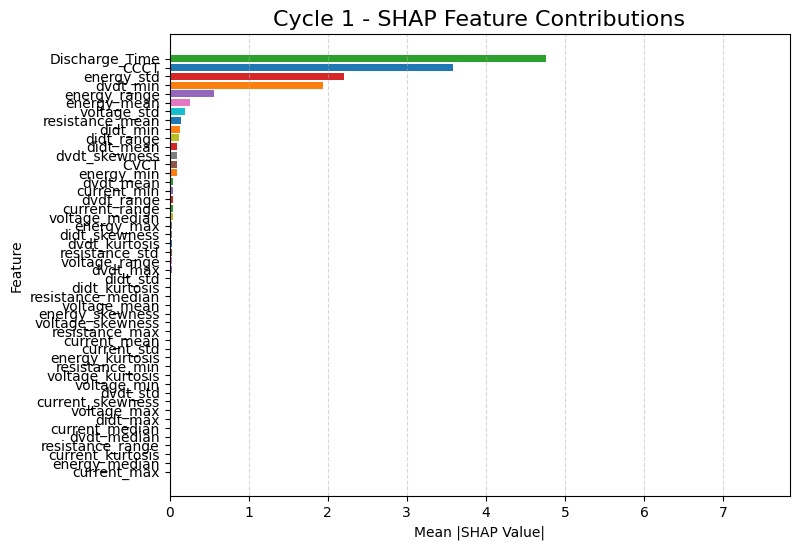

In [12]:
# Step 6：動畫製作（折線圖 or 條形圖皆可）
output_path = 'shap_bar_animation.mp4'
fps = 10                  # 幀率（建議 5~10）
dpi = 120                 # 畫質
speed_up = 1              # 可用 2x 快轉（fps * speed_up）

import matplotlib.pyplot as plt
import matplotlib.animation as animation

# 特徵清單（依照平均 SHAP 排序）
feature_order = shap_df.mean().sort_values(ascending=False).index.tolist()

# 設定顏色：給每個特徵一個隨機顏色（固定）
import random
random.seed(42)
color_map = {feat: f'C{idx % 10}' for idx, feat in enumerate(feature_order)}

# 建立畫布
fig, ax = plt.subplots(figsize=(8, 6))

def update(frame):
    ax.clear()
    cycle = shap_df.index[frame]
    values = shap_df.loc[cycle]

    sorted_values = values.sort_values(ascending=True)  # 從小到大畫
    sorted_features = sorted_values.index
    sorted_shaps = sorted_values.values

    colors = [color_map[feat] for feat in sorted_features]

    ax.barh(sorted_features, sorted_shaps, color=colors)
    ax.set_xlim(0, shap_df.values.max() * 1.1)
    ax.set_title(f"Cycle {cycle} - SHAP Feature Contributions", fontsize=16)
    ax.set_xlabel("Mean |SHAP Value|")
    ax.set_ylabel("Feature")
    ax.grid(axis='x', linestyle='--', alpha=0.5)

# 建立動畫
ani = animation.FuncAnimation(
    fig, update, frames=len(shap_df), interval=1000 / fps
)

# 儲存為 mp4
ani.save(output_path, writer='ffmpeg', dpi=dpi)
print(f"✅ 動畫已儲存：{output_path}")
